In [1]:
from __future__ import annotations

import argparse
import importlib.util
import logging
import sys
import time
import types
from pathlib import Path

from src.utils import pmf_utils
import pandas as pd
import matplotlib.pyplot as plt
import importlib, src.ddm.ddm
importlib.reload(src.ddm.ddm)

import numpy as np
import torch

from config import dir_config

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)


In [2]:
processed_dir = Path(dir_config.data.processed)
ddm_dir = processed_dir / 'ddm'

session_metadata = pd.read_csv(processed_dir / "sessions_metadata.csv")
behavior_df = pd.read_csv(ddm_dir / "behavior_data.csv")

In [3]:
def summarize(df):
    p_upper, mean_rt_upper, mean_rt_lower = [], [], []
    cohs = sorted(df["signed_coherence"] if df["signed_coherence"] is not None else df["signed_coherence"].unique())

    # if coh is between 0 and 1 then convert to percentage
    if cohs and 0 < cohs[0] < 1:
        cohs = [c * 100 for c in cohs]

    for c in cohs:
        subset = df[df["signed_coherence"] == c].dropna(subset=["rt", "choice"])
        p_upper.append((subset["choice"] == 1).mean() if len(subset) > 0 else np.nan)
        upper = subset[subset["choice"] == 1]["rt"]
        lower = subset[subset["choice"] == 0]["rt"]
        mean_rt_upper.append(upper.mean() if len(upper) > 0 else np.nan)
        mean_rt_lower.append(lower.mean() if len(lower) > 0 else np.nan)
    return np.array(cohs), np.array(p_upper), np.array(mean_rt_upper), np.array(mean_rt_lower)

def plot_ddm_fit(data, sim, coherences=None, title="DDM Fit"):
    """
    Overlay observed data (dots) and model predictions (lines).

    data : DataFrame or dict with keys 'rt', 'choice', 'signed_coherence'
    sim  : DataFrame or dict with keys 'rt', 'choice', 'signed_coherence'
    """
    if not isinstance(data, pd.DataFrame):
        data = pd.DataFrame(data)
    if not isinstance(sim, pd.DataFrame):
        sim = pd.DataFrame(sim)

    data = data.copy()
    sim  = sim.copy()
    data["signed_coherence"] = data["signed_coherence"].round(2)
    sim["signed_coherence"]  = sim["signed_coherence"].round(2)

    d_cohs, d_p, d_rt1, d_rt0 = summarize(data)
    s_cohs, s_p, s_rt1, s_rt0 = summarize(sim)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    fig.suptitle(title)

    # --- Psychometric ---
    ax1.plot(s_cohs, s_p, color="steelblue", label="model")
    ax1.scatter(d_cohs, d_p, color="steelblue", zorder=5, label="data")
    ax1.axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
    ax1.axvline(0.0, color="gray", linestyle="--", linewidth=0.8)
    ax1.set(xlabel="Coherence", ylabel="P(upper boundary)", title="Psychometric", ylim=(0, 1))
    ax1.legend()

    # --- Chronometric ---
    ax2.plot(s_cohs, s_rt1, color="steelblue", label="model upper")
    ax2.plot(s_cohs, s_rt0, color="tomato",    label="model lower")
    ax2.scatter(d_cohs, d_rt1, color="steelblue", zorder=5, label="data upper")
    ax2.scatter(d_cohs, d_rt0, color="tomato",    zorder=5, label="data lower")
    ax2.axvline(0.0, color="gray", linestyle="--", linewidth=0.8)
    ax2.set(xlabel="Coherence", ylabel="Mean RT (s)", title="Chronometric")
    ax2.legend()

    plt.tight_layout()
    # return fig

In [4]:
from scripts.ddm.ddm_fitting import build_stimulus, get_job, build_grid

In [5]:
session_ids = session_metadata["session_id"].tolist()
grid = build_grid(behavior_df)
job_lookup = {job_id: get_job(grid, job_id) for job_id in range(len(grid))}
stem_to_job_id = {
    (
        job["session_id"],
        job["prior_block"],
        job["enable_leak"],
        job["enable_time_constant"],
    ): job_id
    for job_id, job in job_lookup.items()
}

missing_job_ids = set()
for sub_dir in ddm_dir.iterdir():

    if not sub_dir.is_dir():
        continue

    # ----------------------------
    # parse variant from folder name
    # ----------------------------
    leak = "leak-1" in sub_dir.name
    tc = "tc-1" in sub_dir.name

    expected = {
        (sid, block, leak, tc)
        for sid in session_ids
        for block in [0, 1]
    }
    print(f"\nChecking directory: {sub_dir.name} (leak={leak}, tc={tc}) with {len(list(sub_dir.rglob('*.pkl')))} model files...")

    found = set()

    for model in sub_dir.rglob("*.pkl"):

        try:
            session = model.stem.split("_prior_block_")[0]
            block = int(model.stem.split("_prior_block_")[1])

            found.add((session, block, leak, tc))

        except Exception as e:
            print(f"[PARSE ERROR] {model}: {e}")

    missing = expected - found
    extra = found - expected

    print(
        f"\n=== {sub_dir.name} ===\n"
        f"Total files: {len(list(sub_dir.rglob('*.pkl')))}\n"
        f"Expected: {len(expected)}\n"
        f"Missing: {len(missing)}\n"
        f"Extra: {len(extra)}"
    )

    # ----------------------------
    # missing reporting
    # ----------------------------
    if missing:
        print("\nMISSING DETAILS:")
        for m in sorted(missing):
            job_id = stem_to_job_id.get(m)

            print(f"{m} → job_id={job_id}")

            if job_id is not None:
                missing_job_ids.add(job_id)


print("\n=== SUMMARY ===")
print("Missing job IDs:", sorted(missing_job_ids))


Checking directory: leak-0_tc-1 (leak=False, tc=True) with 90 model files...

=== leak-0_tc-1 ===
Total files: 90
Expected: 90
Missing: 0
Extra: 0

Checking directory: leak-1_tc-1 (leak=True, tc=True) with 90 model files...

=== leak-1_tc-1 ===
Total files: 90
Expected: 90
Missing: 0
Extra: 0

Checking directory: leak-0_tc-0 (leak=False, tc=False) with 90 model files...

=== leak-0_tc-0 ===
Total files: 90
Expected: 90
Missing: 0
Extra: 0

Checking directory: leak-1_tc-0 (leak=True, tc=False) with 90 model files...

=== leak-1_tc-0 ===
Total files: 90
Expected: 90
Missing: 0
Extra: 0

=== SUMMARY ===
Missing job IDs: []


# Session Wise Model Fits

In [6]:
import pickle

from scripts.ddm.ddm_fitting import DDMModel

In [7]:
# calculate cumulative likelihood for all model types
cumulative_likelihoods = {}

# calculate aic for all model types
aic_values = {}


leaks = [0, 1]
tcs = [0, 1]
PARAM_COUNTS = {
    "leak-0_tc-0": 5,  # ndt, a, z, drift_gain, drift_offset
    "leak-0_tc-1": 6,  # + time_constant
    "leak-1_tc-0": 6,  # + leak_rate
    "leak-1_tc-1": 7,  # + both
}

for leak in leaks:
    for tc in tcs:
        model_type = f"leak-{leak}_tc-{tc}"
        pkl_files = list((ddm_dir / model_type).glob("*.pkl"))
        failed = list((ddm_dir / model_type).glob("*.FAILED.json"))
        if failed:
            raise

for leak in leaks:
    for tc in tcs:
        model_type = f"leak-{leak}_tc-{tc}"
        model_path = ddm_dir / model_type

        pkl_files = list(model_path.glob("*.pkl"))

        total_nll = 0
        for pkl_file in pkl_files:
            try:
                with open(pkl_file, "rb") as f:
                    model = pickle.load(f)
                    total_nll += model['results']['likelihood']
            except Exception as e:
                print(f"Error loading {pkl_file}: {e}")

        k = PARAM_COUNTS[model_type]
        cumulative_likelihoods[model_type] = np.round(total_nll)
        aic_values[model_type] = 2 * k + 2 * np.round(total_nll)  # since NLL is positive

# capture key with highest likelihood (lowest NLL) and lowest AIC
best_likelihood_model = min(cumulative_likelihoods, key=cumulative_likelihoods.get)
best_aic_model = min(aic_values, key=aic_values.get)

if best_likelihood_model == best_aic_model:
    best_model = best_likelihood_model
    print(f"Best model by both likelihood and AIC: {best_model}")
else:
    print(f"Best model by likelihood: {best_likelihood_model}")
    print(f"Best model by AIC: {best_aic_model}")

Best model by both likelihood and AIC: leak-1_tc-1


In [8]:
model_dir = ddm_dir / best_model

In [9]:
from scripts.ddm.ddm_fitting import build_stimulus, prepare_data

In [10]:
for idx, model_path in enumerate(model_dir.rglob("*.pkl")):
    print(f"Loading {model_path}...")
    try:
        model = pickle.load(open(model_path, "rb"))
        parameters = model['results']['parameters']
        parameters["dt"] = 0.001
    except Exception as e:
        print(f"Error loading {model_path}: {e}")

    if idx == 0:
        break

Loading /mnt/prior-data/processed/ddm/leak-1_tc-1/210126_GP_JP_prior_block_1.pkl...


In [11]:
def get_stimulus(model_path):
    session_data = prepare_data(
        behavior_df,
        session_id=model_path.stem.split("_prior_block_")[0],
        prior_block=int(model_path.stem.split("_prior_block_")[1]),
    )
    stimulus = build_stimulus(session_data)
    return session_data, stimulus

session_data, stimulus = get_stimulus(model_path)


In [13]:
from scripts.ddm.ddm_fitting import DDMModel

test = DDMModel(
    enable_leak=parameters.get("enable_leak", False),
    enable_time_constant=parameters.get("enable_time_constant", False),
    device='cuda',
    likelihood_params={
        "caf_weight": 0.5,
        "caf_bins": 5,
        "rt_var_weight": 1.0
        }
)

INFO:src.ddm.ddm:Using device: cuda
INFO:src.ddm.ddm:Initialized DDMModel | device=cuda


In [14]:
test.

In [49]:
sim_data= model['model'].simulate(
    stimulus=stimulus,
    params=parameters,
    n_reps=1
)
sim_data = pd.DataFrame(sim_data)
sim_data['signed_coherence'] = sim_data['signed_coherence'] # convert back to proportion
sim_data

,rt,choice,signed_coherence
0,NaN,NaN,0.50
1,NaN,NaN,0.20
2,NaN,NaN,-0.50
3,NaN,NaN,-0.20
4,NaN,NaN,0.06
...,...,...,...
594,NaN,NaN,-0.20
595,NaN,NaN,0.50
596,NaN,NaN,0.20
597,NaN,NaN,0.50


In [ ]:
from src.ddm.ddm import LikelihoodCalculator


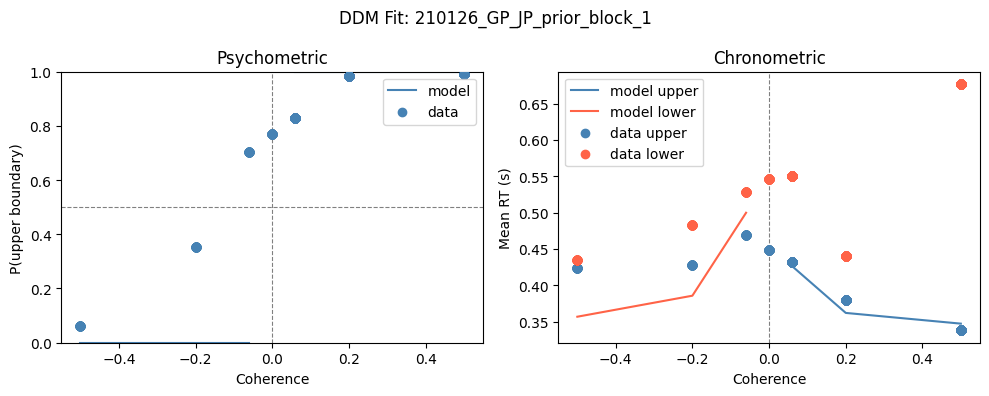

In [25]:
plot_ddm_fit(
    data=session_data,
    sim=sim_data,
    title=f"DDM Fit: {model_path.stem}"
)

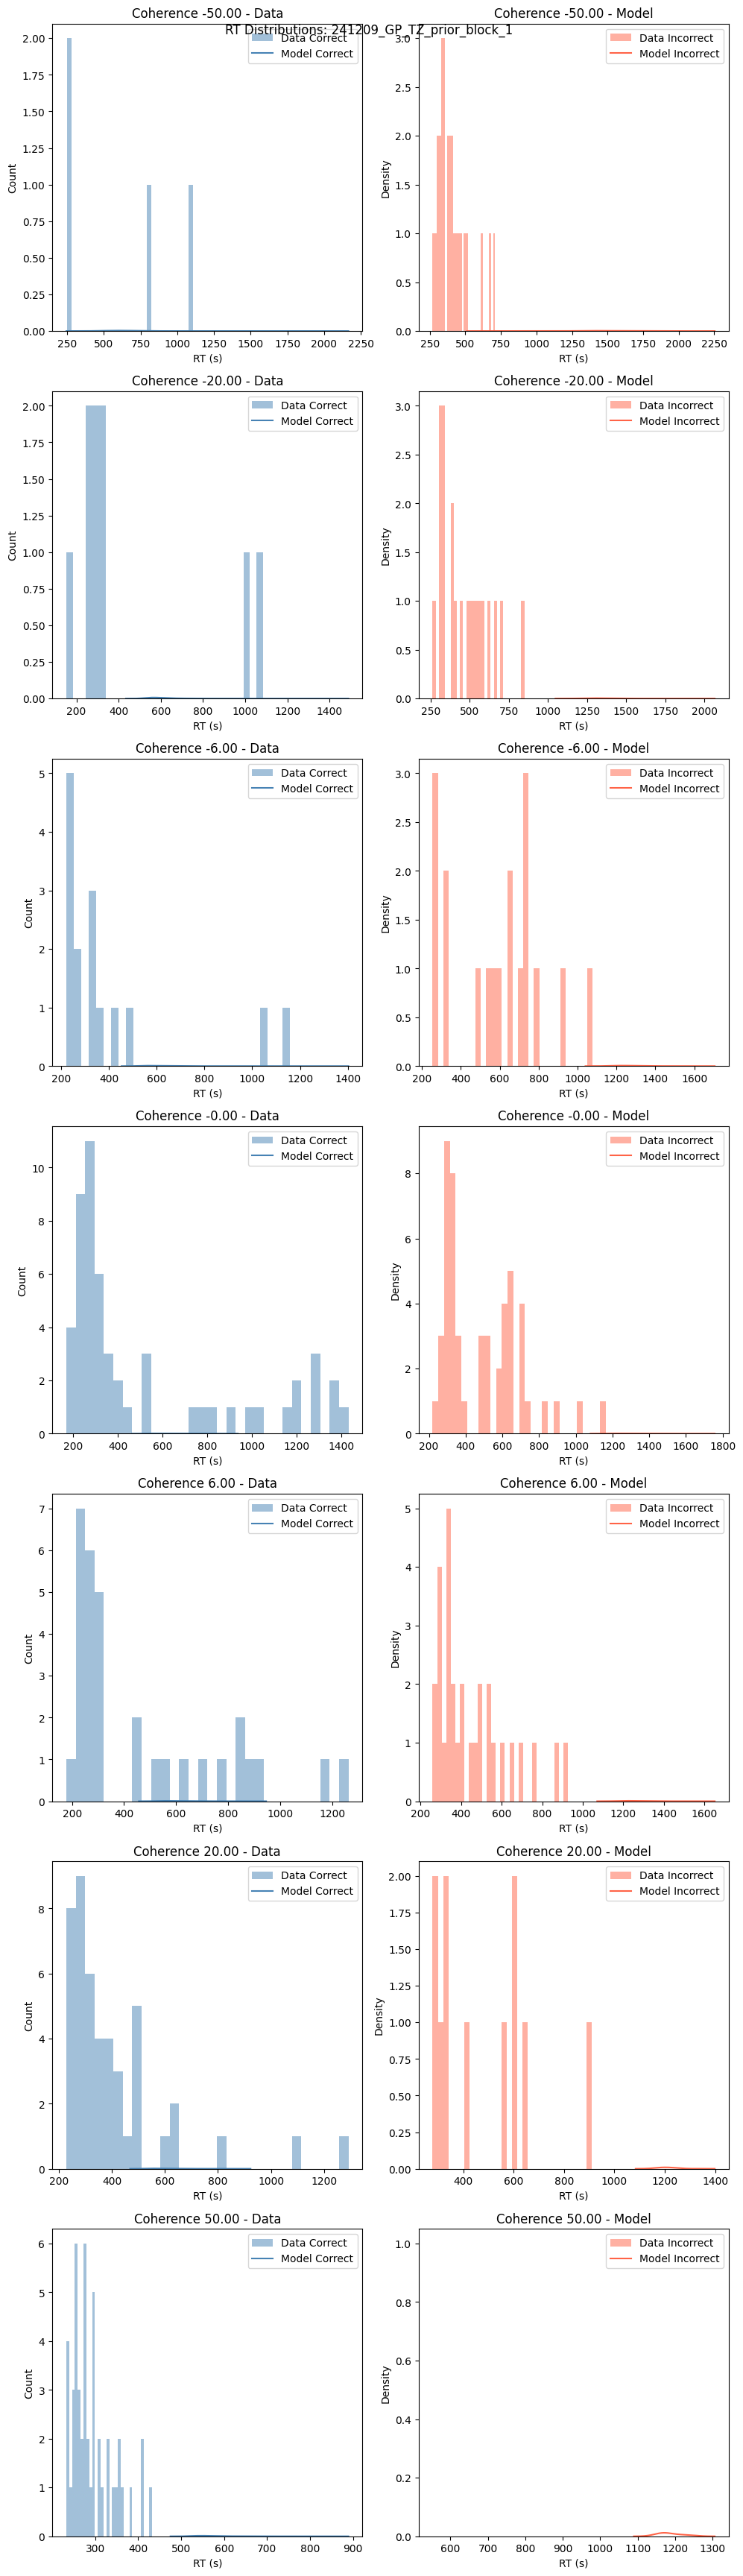

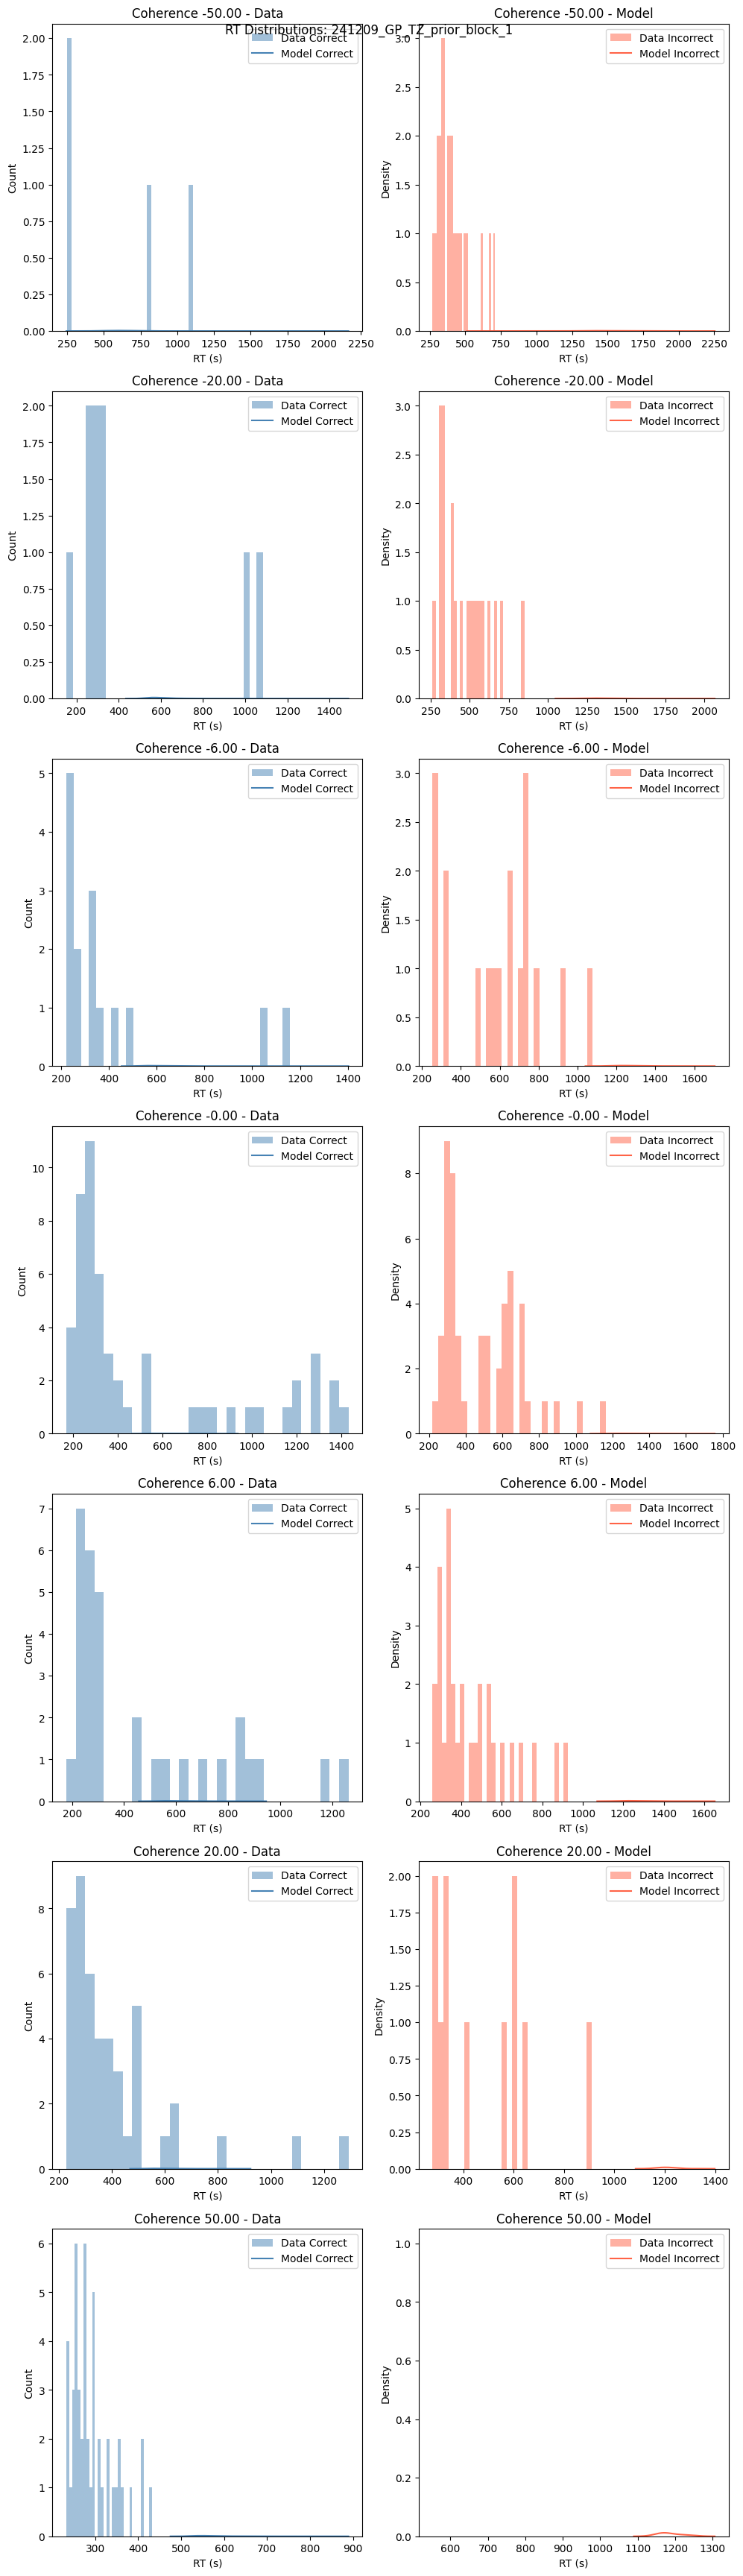

In [ ]:
import seaborn as sns

# plot RT distributions for each coherence, correct and incorrect separately in data and sim. Data should be hist and sim should be kde. This will help us see if the model is capturing the shape of the RT distributions, not just the means.
def plot_rt_distributions(data, sim, coherences=None, title="RT Distributions"):

    if not isinstance(data, pd.DataFrame):
        data = pd.DataFrame(data)
    if not isinstance(sim, pd.DataFrame):
        sim = pd.DataFrame(sim)

    data = data.copy()
    sim  = sim.copy()
    data["signed_coherence"] = data["signed_coherence"].round(2)
    sim["signed_coherence"]  = sim["signed_coherence"].round(2)

    cohs = sorted(coherences if coherences is not None else data["signed_coherence"].unique())

    fig, axes = plt.subplots(len(cohs), 2, figsize=(10, 5 * len(cohs)))
    fig.suptitle(title)

    for i, c in enumerate(cohs):
        d_subset = data[data["signed_coherence"] == c].dropna(subset=["rt", "choice"])
        s_subset = sim[sim["signed_coherence"] == c].dropna(subset=["rt", "choice"])

        d_correct = d_subset[d_subset["choice"] == 1]["rt"]
        d_incorrect = d_subset[d_subset["choice"] == 0]["rt"]
        s_correct = s_subset[s_subset["choice"] == 1]["rt"]
        s_incorrect = s_subset[s_subset["choice"] == 0]["rt"]

        axes[i, 0].hist(d_correct, bins=30, alpha=0.5, label="Data Correct", color="steelblue")
        sns.kdeplot(s_correct, label="Model Correct", color="steelblue", ax=axes[i, 0])
        axes[i, 0].set_title(f"Coherence {c:.2f} - Data")
        axes[i, 0].set_xlabel("RT (s)")
        axes[i, 0].set_ylabel("Count")
        axes[i, 0].legend()

        axes[i, 1].hist(d_incorrect, bins=30, alpha=0.5, label="Data Incorrect", color="tomato")
        sns.kdeplot(s_incorrect, label="Model Incorrect", color="tomato", ax=axes[i, 1])
        axes[i, 1].set_title(f"Coherence {c:.2f} - Model")
        axes[i, 1].set_xlabel("RT (s)")
        axes[i, 1].set_ylabel("Density")
        axes[i, 1].legend()
    plt.tight_layout()
    return fig

plot_rt_distributions(
    data=session_data,
    sim=sim_data,
    title=f"RT Distributions: {model_path.stem}"
)

# SCRATCH BOOK

In [ ]:
from dataclasses import dataclass
DEFAULT_PARAMS: dict = {
    "ndt":          0.1,
    "a":            2.0,
    "z":            0.5,
    "drift_gain":   7.0,
    "drift_offset": 0.0,
    "variance":     1.0,
    "dt":           0.001,
    "leak_rate":    0.0,
    "time_constant": 0.0,
}

from src.ddm.ddm2 import DecisionModel, validate_params, ParamSpec

class SimpleModel(DecisionModel):

    def param_specs(self):
        return {
            "ndt":          ParamSpec(0.1, 1.0),
            "a":            ParamSpec(0.8, 6.0),
            "z":            ParamSpec(0.1, 0.9),
            "drift_gain":   ParamSpec(1.0, 10.0),
            "drift_offset": ParamSpec(-5.0, 5.0),

            "leak_rate":    ParamSpec(0.0, 1.0),
            "variance":     ParamSpec(0.5, 2.0),
            "time_constant":ParamSpec(-2.0, 2.0),
        }

    def get_fit_keys(self):
        return [k for k, spec in self.param_specs.items() if spec.fit]

    def _build_params(self, values: np.ndarray, condition_idx: int | None = None) -> dict:
        p = dict(DEFAULT_PARAMS)

        fit_keys = self.get_fit_keys()

        for key, val in zip(fit_keys, values):
            p[key] = val

        # fill fixed parameters
        for key, spec in self.param_specs.items():
            if not spec.fit:
                p[key] = spec.init

        return p

model = SimpleModel()


INFO:src.ddm.ddm2:Initialized SimpleModel | device=CPU


<bound method SimpleModel._build_params of <__main__.SimpleModel object at 0x7ab5f41697b0>>